In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

In [6]:
sar_file = list(Path("../../data/sar/sar_samples").glob("*.tiff"))[0]

with rasterio.open(sar_file) as src:
    sar_crs = src.crs
    sar_bounds = src.bounds
    sar_width = src.width
    sar_height = src.height
    sar_bands = src.count

print("SAR file:", sar_file.name)
print("CRS:", sar_crs)
print("Bounds:", sar_bounds)
print("Width:", sar_width)
print("Height:", sar_height)
print("Bands:", sar_bands)

SAR file: S1A_IW_GRDH_1SDV_20200723T061222_20200723T061247_033578_03E42D_AD34.tiff
CRS: None
Bounds: BoundingBox(left=0.0, bottom=4167.0, right=6657.0, top=0.0)
Width: 6657
Height: 4167
Bands: 1


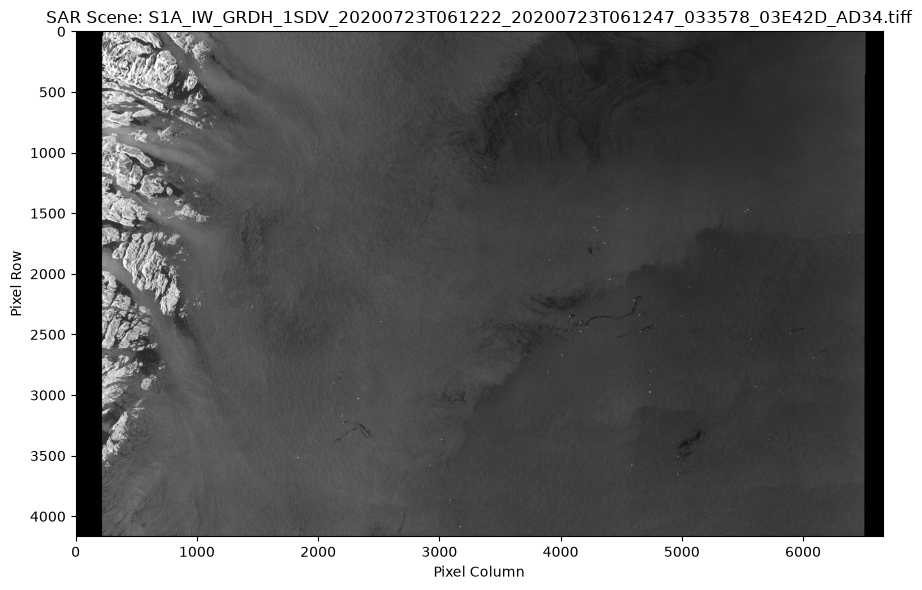

In [7]:
with rasterio.open(sar_file) as src:
    sar_image = src.read(1)

plt.figure(figsize=(10, 6))
plt.imshow(sar_image, cmap="gray")
plt.title(f"SAR Scene: {sar_file.name}")
plt.xlabel("Pixel Column")
plt.ylabel("Pixel Row")
plt.tight_layout()
plt.show()

In [8]:
ais_file = Path("../../data/ais/ais-2025-01-08.csv.zst")

ais = pd.read_csv(
    ais_file,
    compression="zstd"
)

ais["base_date_time"] = pd.to_datetime(
    ais["base_date_time"],
    utc=True
)

print("Rows:", len(ais))
print("Time:", ais["base_date_time"].min(), "to", ais["base_date_time"].max())
print("Longitude:", ais["longitude"].min(), "to", ais["longitude"].max())
print("Latitude:", ais["latitude"].min(), "to", ais["latitude"].max())
print("Unique MMSIs:", ais["mmsi"].nunique())

Rows: 5929631
Time: 2025-01-08 00:00:00+00:00 to 2025-01-08 23:59:59+00:00
Longitude: -175.14678 to 146.49848
Latitude: 2.30697 to 85.28678
Unique MMSIs: 16294


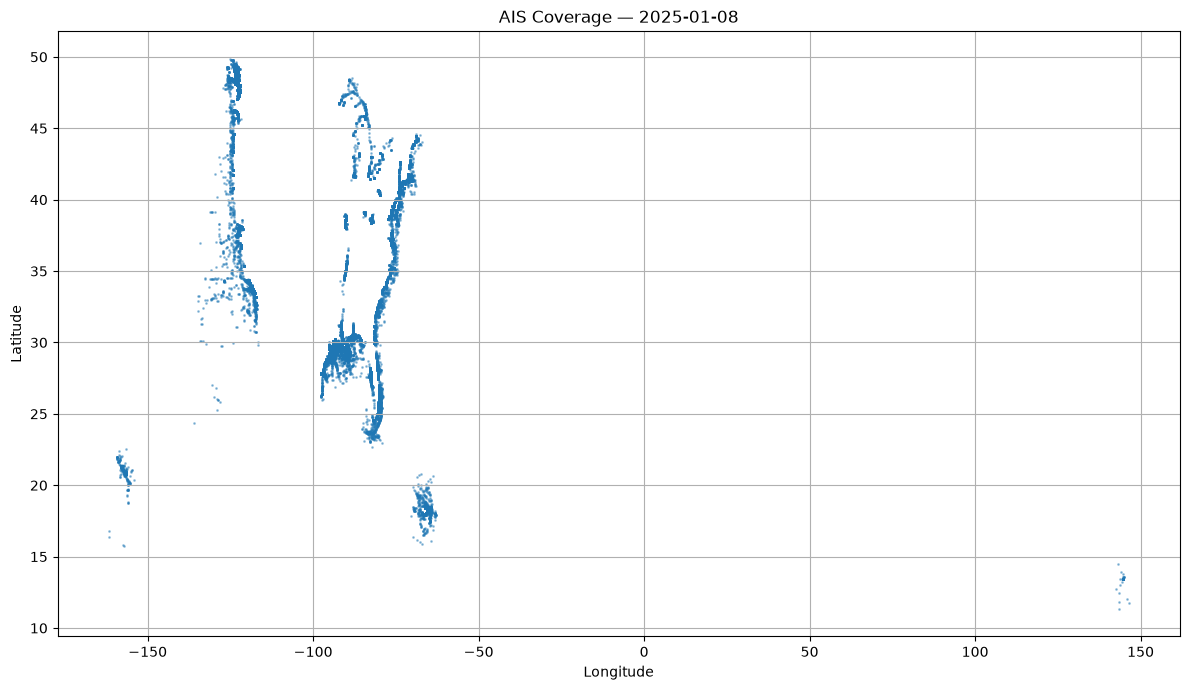

In [9]:
ais_plot = ais.sample(
    n=min(50000, len(ais)),
    random_state=42
)

plt.figure(figsize=(12, 7))

plt.scatter(
    ais_plot["longitude"],
    ais_plot["latitude"],
    s=1,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("AIS Coverage — 2025-01-08")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
quality = {
    "SOG missing (%)": ais["sog"].isna().mean() * 100,
    "COG missing (%)": ais["cog"].isna().mean() * 100,
    "Duplicate rows (%)": ais.duplicated().mean() * 100,
    "Valid coordinates (%)": (
        ais["longitude"].between(-180, 180)
        & ais["latitude"].between(-90, 90)
    ).mean() * 100
}

quality_df = pd.DataFrame(
    quality.items(),
    columns=["Metric", "Value"]
)

quality_df

,Metric,Value
0,SOG missing (%),0.211480
1,COG missing (%),18.040920
2,Duplicate rows (%),0.018635
3,Valid coordinates (%),100.000000


In [11]:
contradictions = pd.DataFrame([
    {
        "Check": "SAR acquisition date",
        "Manifest claim": "2026-09-02",
        "Verified repository evidence": "2020-07-23 from selected TIFF filename",
        "Status": "CONTRADICTION"
    },
    {
        "Check": "SAR CRS",
        "Manifest claim": "EPSG:4326",
        "Verified repository evidence": "CRS=None",
        "Status": "CONTRADICTION / UNSUPPORTED"
    },
    {
        "Check": "SAR geographic bounds",
        "Manifest claim": "Geographic scene bounds implied",
        "Verified repository evidence": "Raster bounds are pixel coordinates 0–6657 / 0–4167",
        "Status": "UNAVAILABLE"
    },
    {
        "Check": "AIS time range",
        "Manifest claim": "2025-01-08",
        "Verified repository evidence": "2025-01-08 00:00:00 to 23:59:59 UTC",
        "Status": "CONSISTENT"
    },
    {
        "Check": "AIS vs drift temporal overlap",
        "Manifest claim": "Origin window 2026-09-01",
        "Verified repository evidence": "AIS only covers 2025-01-08",
        "Status": "NO OVERLAP"
    },
    {
        "Check": "AIS coordinates",
        "Manifest claim": "Provided bounding box",
        "Verified repository evidence": "-175.14678 to 146.49848 lon; 2.30697 to 85.28678 lat",
        "Status": "VERIFIED"
    },
    {
        "Check": "Prototype georeferencing",
        "Manifest claim": "Observed centroid [71.058396, 19.495814]",
        "Verified repository evidence": "Manifest explicitly says coordinates are injected",
        "Status": "NOT GROUND-TRUTH VERIFIED"
    },
    {
        "Check": "Environmental forcing",
        "Manifest claim": "Wind/current parameters",
        "Verified repository evidence": "No source dataset/metadata available",
        "Status": "NOT DATA-BACKED"
    }
])

contradictions

,Check,Manifest claim,Verified repository evidence,Status
0,SAR acquisition date,2026-09-02,2020-07-23 from selected TIFF filename,CONTRADICTION
1,SAR CRS,EPSG:4326,CRS=None,CONTRADICTION / UNSUPPORTED
2,SAR geographic bounds,Geographic scene bounds implied,Raster bounds are pixel coordinates 0–6657 / 0...,UNAVAILABLE
3,AIS time range,2025-01-08,2025-01-08 00:00:00 to 23:59:59 UTC,CONSISTENT
4,AIS vs drift temporal overlap,Origin window 2026-09-01,AIS only covers 2025-01-08,NO OVERLAP
5,AIS coordinates,Provided bounding box,-175.14678 to 146.49848 lon; 2.30697 to 85.286...,VERIFIED
6,Prototype georeferencing,"Observed centroid [71.058396, 19.495814]",Manifest explicitly says coordinates are injected,NOT GROUND-TRUTH VERIFIED
7,Environmental forcing,Wind/current parameters,No source dataset/metadata available,NOT DATA-BACKED
